# Data gathering and preprocessing

## Imports

In [73]:
import kagglehub
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
kagglehub.dataset_download("jessemostipak/hotel-booking-demand", output_dir="./Dataset")
ds = pd.read_csv("./Dataset/hotel_bookings.csv").sample(10000, random_state=268555)

## Data checks

### Understanding given data

In [74]:
ds.info()

def printMissingDataSummary(ds):
    missingCount = ds.isna().sum()
    missingPercentage = (missingCount / len(ds) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(ds)

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 25367 to 93520
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           10000 non-null  object 
 1   is_canceled                     10000 non-null  int64  
 2   lead_time                       10000 non-null  int64  
 3   arrival_date_year               10000 non-null  int64  
 4   arrival_date_month              10000 non-null  object 
 5   arrival_date_week_number        10000 non-null  int64  
 6   arrival_date_day_of_month       10000 non-null  int64  
 7   stays_in_weekend_nights         10000 non-null  int64  
 8   stays_in_week_nights            10000 non-null  int64  
 9   adults                          10000 non-null  int64  
 10  children                        10000 non-null  float64
 11  babies                          10000 non-null  int64  
 12  meal                            1

### Dealing with missing data #1

In [75]:
ds.drop(columns=["company"], inplace=True)
ds = ds.loc[ds["country"].notna()].copy()
ds = ds.loc[ds["children"].notna()].copy()

### Dealing with strings in data (optional)

In [76]:
ds.describe(include="object")

for col in ds.select_dtypes(include=['object']).columns:
    if col != 'reservation_status_date':
        ds[col] = ds[col].astype('category').cat.codes
    else:
        ds["reservation_status_date"] = pd.to_datetime(ds["reservation_status_date"], errors="coerce")

ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9957 entries, 25367 to 93520
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           9957 non-null   int8          
 1   is_canceled                     9957 non-null   int64         
 2   lead_time                       9957 non-null   int64         
 3   arrival_date_year               9957 non-null   int64         
 4   arrival_date_month              9957 non-null   int8          
 5   arrival_date_week_number        9957 non-null   int64         
 6   arrival_date_day_of_month       9957 non-null   int64         
 7   stays_in_weekend_nights         9957 non-null   int64         
 8   stays_in_week_nights            9957 non-null   int64         
 9   adults                          9957 non-null   int64         
 10  children                        9957 non-null   float64       
 11  babi

### Dealing with time in data

In [77]:
ds['arrival_date_month'] = ds['arrival_date_month'] + 1

ds['arrival_date'] = pd.to_datetime(
    ds['arrival_date_year'].astype(str) + '-' +
    ds['arrival_date_month'].astype(str) + '-' +
    ds['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

ds = ds[ds['arrival_date'].notna()].copy()

ds.drop(columns=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], inplace=True)

### Dealing with orphans

In [78]:
ds = ds[ds['adults'] != 0]

### Dealing with missing data #2

In [79]:
trainDf = ds[ds["agent"].notna()].copy()
predictDf = ds[ds["agent"].isna()].copy()

y = trainDf["agent"]
X = trainDf.drop(columns=["agent"])
predX = predictDf.drop(columns=["agent"])

catCols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numCols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore"), catCols),
        ("num", "passthrough", numCols),
    ]
)

model = sklearn.pipeline.Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=268555))
])

trainX, valX, trainY, valY = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=268555)

model.fit(trainX, trainY)
print("val score:", model.score(valX, valY))

predictedAgents = model.predict(predX)

ds.loc[ds["agent"].isna(), "agent"] = predictedAgents

val score: 0.821301775147929


In [80]:
printMissingDataSummary(ds)


Missing data summary:
                                missingCount  missingPercentage
hotel                                      0                0.0
is_canceled                                0                0.0
lead_time                                  0                0.0
arrival_date_week_number                   0                0.0
stays_in_weekend_nights                    0                0.0
stays_in_week_nights                       0                0.0
adults                                     0                0.0
children                                   0                0.0
babies                                     0                0.0
meal                                       0                0.0
country                                    0                0.0
market_segment                             0                0.0
distribution_channel                       0                0.0
is_repeated_guest                          0                0.0
previous_cancella

In [81]:
def printColumnValueCounts(ds):
    print(ds.nunique(dropna=False))

    rows = []
    for col in ds.columns:
        counts = ds[col].value_counts(dropna=False).sort_values(ascending=False)
        for val, cnt in counts.items():
            rows.append({
                "column": col,
                "value": str(val),
                "count": cnt
            })

    result = pd.DataFrame(rows)
    result.to_csv("column_value_counts.csv", index=False, encoding="utf-8-sig")
    print("Wrote", len(result), "rows to column_value_counts.csv")

printColumnValueCounts(ds)

hotel                                2
is_canceled                          2
lead_time                          436
arrival_date_week_number            53
stays_in_weekend_nights             11
stays_in_week_nights                23
adults                               4
children                             4
babies                               3
meal                                 5
country                            111
market_segment                       7
distribution_channel                 4
is_repeated_guest                    2
previous_cancellations              12
previous_bookings_not_canceled      29
reserved_room_type                   8
assigned_room_type                  10
booking_changes                      9
deposit_type                         3
agent                              216
days_in_waiting_list                85
customer_type                        4
adr                               2134
required_car_parking_spaces          3
total_of_special_requests

### Correlation matrix presentation

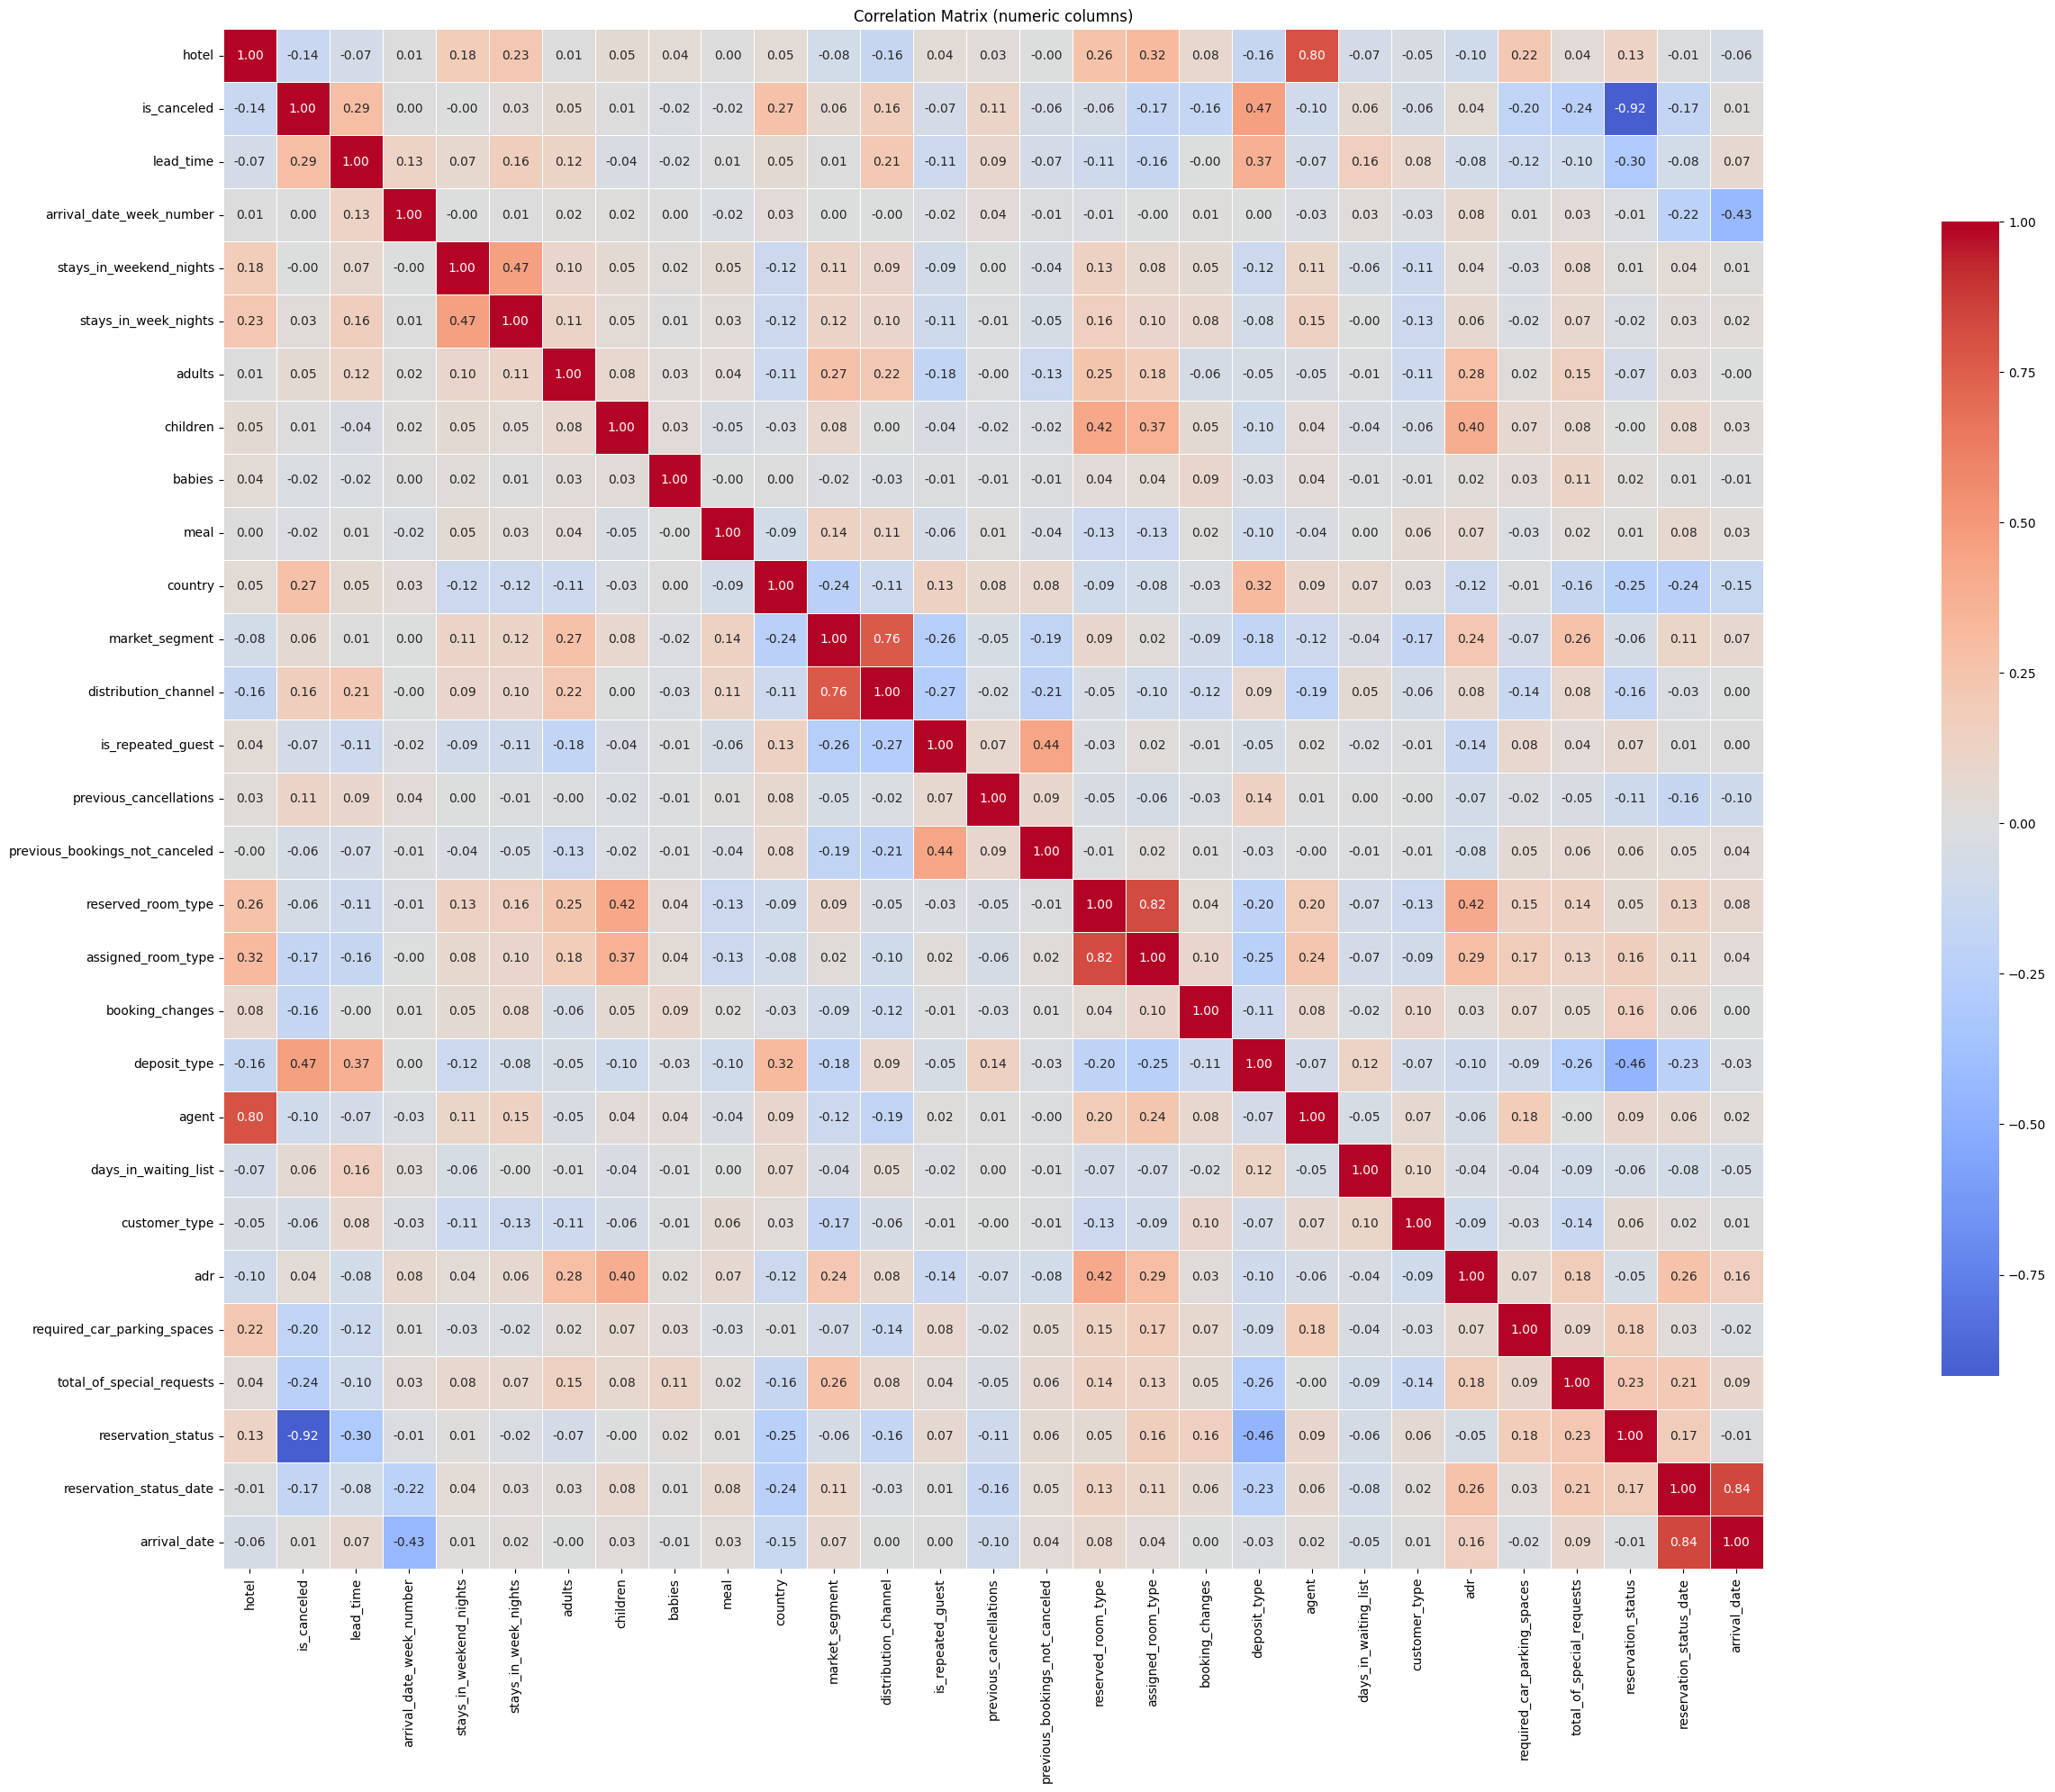

In [82]:
def printComputationMatrix(ds):
    corr = ds.corr()

    plt.figure(figsize=(40, 20))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75}
    )
    plt.title("Correlation Matrix (numeric columns)")
    plt.tight_layout()
plt.show()

printComputationMatrix(ds)